URL index: [Home](https://zzz.bwh.harvard.edu/luna-walkthrough/) | [Data](https://zzz.bwh.harvard.edu/luna-walkthrough/data/) | [S1. File QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p1/) | [S2. Signal QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p2) | [S3. Staging](https://zzz.bwh.harvard.edu/luna-walkthrough/p3) | [S4. Artifacts](https://zzz.bwh.harvard.edu/luna-walkthrough/p4) | [S5. Analysis](https://zzz.bwh.harvard.edu/luna-walkthrough/p5)

Notebook index: [Index](../00_index.ipynb) | [S1. File QC](../p1/00_index.ipynb) | [S2. Signal QC](../p2/00_index.ipynb) | [S3. Staging](../p3/00_index.ipynb) | [S4. Artifacts](../p4/00_index.ipynb) | [S5. Analysis](../p5/00_index.ipynb)

---

# 5.1. Macro-architecture

Walkthrough URL = [https://zzz.bwh.harvard.edu/luna-walkthrough/p5/macro](https://zzz.bwh.harvard.edu/luna-walkthrough/p5/macro)

---



In [1]:
import lunapi as lp
proj = lp.proj()
proj.sample_list( '../c.lst' )

initiated lunapi v1.2.3 <lunapi.lunapi0.luna object at 0x105a48870> 

read 20 individuals from ../c.lst


We also need to make some new folders for outputs, and attach some helper functions:

In [2]:
import os, sys

sys.path.append('../')

from helperfuncs import fit_lm, fit_lms, safe_to_numeric

for path in ['../out', '../res']: 
    os.makedirs(path, exist_ok=True)

## Running HYPNO

In [3]:
# luna c.lst -o out/hypno.db -s HYPNO epoch
res = proj.silent_proc( 'HYPNO epoch' ) 

In [4]:
# destrat  out/hypno.db +HYPNO > res/hypno.base
df_base = proj.table( 'HYPNO' ) 

In [34]:
# destrat  out/hypno.db +HYPNO -r SS/N1,N2,N3,R,W > res/hypno.stage
df_stg = proj.table( 'HYPNO' , 'SS' )
df_stg = df_stg[ df_stg.SS.isin( ['N1','N2','N3','NR','R','S','W','WASO' ] ) ]

In [6]:
# destrat  out/hypno.db +HYPNO -r C/1,2,3,4  > res/hypno.cycle
df_cyc = proj.table( 'HYPNO' , 'C' )
df_cyc = df_cyc[ df_cyc.C.isin( [1,2,3,4] ) ]

## Baseline metrics

We'll read and merge in the covariate (age/sex) data:

In [7]:
# p <- read.table("work/data/auxiliary/master.txt", header=T, stringsAsFactors=F)
import pandas as pd
p = pd.read_csv( '../work/data/auxiliary/master.txt' , sep="\t" ) 
p

,ID,male,age
0,F01,0,41
1,F02,0,32
2,F03,0,37
3,F04,0,32
4,F05,0,30
5,F06,0,32
6,F07,0,33
7,F08,0,40
8,F09,0,44
9,F10,0,34


In [8]:
# d <- merge( d , p , by="ID" ) 
df_base = pd.merge( p , df_base , on = 'ID' ) 
df_base = safe_to_numeric( df_base )
df_base

,ID,male,age,CONF,E0_START,E1_LIGHTS_OFF,E2_SLEEP_ONSET,E3_SLEEP_MIDPOINT,E4_FINAL_WAKE,E5_LIGHTS_ON,...,TGT,TIB,TI_RNR,TI_S,TI_S3,TRT,TST,TST_PER,TWT,WASO
0,F01,0,41,0,0,0.0,37.5,227.75,418.0,421.5,...,0.0,421.5,0.020528,0.155425,0.160315,421.5,341.0,279.5,80.5,39.5
1,F02,0,32,0,0,0.0,19.0,223.00,427.0,430.5,...,0.0,430.5,0.055556,0.196970,0.147059,430.5,396.0,358.0,34.5,12.0
2,F03,0,37,0,0,0.0,17.0,225.75,434.5,435.0,...,0.0,435.0,0.038043,0.255435,0.244311,435.0,368.0,266.0,67.0,49.5
3,F04,0,32,0,0,0.0,25.5,232.00,438.5,438.5,...,0.0,438.5,0.013913,0.229565,0.181598,438.5,287.5,217.0,151.0,125.5
4,F05,0,30,0,0,0.0,20.0,233.75,447.5,448.0,...,0.0,448.0,0.014025,0.204769,0.184795,448.0,356.5,297.5,91.5,71.0
5,F06,0,32,0,0,0.0,3.0,204.00,405.0,408.5,...,0.0,408.5,0.059126,0.195373,0.156716,408.5,389.0,353.5,19.5,13.0
6,F07,0,33,0,0,0.0,9.5,240.75,472.0,472.0,...,0.0,472.0,0.047319,0.205047,0.151351,472.0,317.0,225.5,155.0,145.5
7,F08,0,40,0,0,0.0,33.5,227.25,421.0,421.0,...,0.0,421.0,0.016949,0.313559,0.240000,421.0,354.0,233.0,67.0,33.5
8,F09,0,44,0,0,0.0,0.0,194.50,389.0,389.5,...,0.0,389.5,0.013680,0.177839,0.118252,389.5,365.5,349.5,24.0,23.5
9,F10,0,34,0,0,0.0,3.5,206.25,409.0,460.5,...,0.0,460.5,0.021680,0.273713,0.172626,460.5,369.0,333.5,91.5,36.5


A box-plot of sleep period time (SPT) in males versus females:

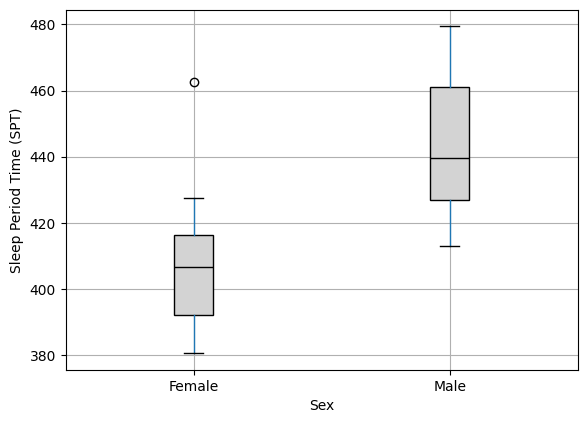

In [42]:
# boxplot( d$SPT ~ rep(c("Female","Male"),each=10) , col = c("red","blue" ), 
#         xlab = "Sex" , ylab = "Sleep Period Time (SPT)" ) 

import matplotlib.pyplot as plt

df_base['Sex'] = ['Female'] * 10 + ['Male'] * 10  

df_base.boxplot(column='SPT', by='Sex', patch_artist=True,
                boxprops=dict(facecolor='lightgray'),
                medianprops=dict(color='black'))

plt.xlabel("Sex")
plt.ylabel("Sleep Period Time (SPT)")
plt.title("")  
plt.suptitle("")  
plt.show()

Fitting a linear model: SPT regressed on age plus sex (removing outliers as needed):

In [10]:
model = fit_lm( 'SPT', df_base ) 
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     DV   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     9.402
Date:                Fri, 13 Jun 2025   Prob (F-statistic):            0.00178
Time:                        09:52:42   Log-Likelihood:                -87.638
No. Observations:                  20   AIC:                             181.3
Df Residuals:                      17   BIC:                             184.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    479.9224     32.074     14.963      0.0

To get the mean SPT stratified by sex:

In [11]:
# tapply( d$SPT , d$male , mean )  / 60 
df_base.groupby('male')['SPT'].mean() / 60

male
0    6.821667
1    7.401667
Name: SPT, dtype: float64

## Stage-specific metrics

## Bout/transition metrics

## NREM cycle metrics

## Hypnogram visualization

## Summary

To generate a table of associations between these 

In [12]:
vars = ['TRT','TIB','SPT','TST','TST_PER','TWT','WASO','SE',
        'SME','SOL','REM_LAT', 'REM_LAT2' ]

fit_lms( vars , df_base )

,Var,Beta,p-value
0,TRT,35.263251,0.004128
1,TIB,35.263251,0.004128
2,SPT,38.181918,0.000896
3,TST,23.607587,0.188301
4,TST_PER,-4.981661,0.837669
5,TWT,11.655664,0.615549
6,WASO,14.574331,0.479714
7,SE,-1.349545,0.777548
8,SME,-2.477243,0.582492
9,SOL,-5.985756,0.266743


That is, although males have significantly longer SPT and also longer time in bed (TIB) and total recording time (TRT), there are actually no (significant) group differences in total sleep time (TST) or wake times (TWT or WASO), nor on sleep efficiency or onset latencies.

As we don't have explicit lights-off and lights-on annotations present, the TRT and TIB metrics are identical here (i.e. lights off is assumed to be the start of the recording, etc)

## Stage-specific metrics

In [35]:
# d <- k$HYPNO$SS
# d <- merge( d , p , by="ID" )
df_stg = pd.merge( p , df_stg , on = 'ID' ) 
df_stg = safe_to_numeric( df_stg )
df_stg

,ID,male,age,SS,BOUT_05,BOUT_10,BOUT_MD,BOUT_MN,BOUT_MX,BOUT_N,DENS,MINS,PCT,TA,TS
0,F01,0,41,N1,5.5,0.0,0.50,1.057692,5.5,26,0.072273,27.5,0.080645,0.432895,0.441997
1,F01,0,41,N2,148.0,112.5,2.25,6.016667,46.0,30,0.474376,180.5,0.529326,0.576316,0.600587
2,F01,0,41,N3,74.0,59.0,10.00,18.500000,48.0,4,0.194481,74.0,0.217009,0.131579,0.146843
3,F01,0,41,NR,272.5,263.5,12.00,20.142857,61.5,14,0.741130,282.0,0.826979,0.467105,0.480176
4,F01,0,41,R,19.5,0.0,2.50,2.950000,9.0,20,0.155059,59.0,0.173021,0.677632,0.704846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,M10,1,41,NR,282.5,218.0,4.50,8.448718,41.5,39,0.755734,329.5,0.852523,0.448909,0.462435
156,M10,1,41,R,37.0,37.0,4.00,5.181818,13.5,11,0.130734,57.0,0.147477,0.559127,0.577720
157,M10,1,41,S,330.0,259.5,4.50,8.588889,41.5,45,0.886468,386.5,1.000000,0.483352,NaN
158,M10,1,41,W,13.5,0.0,0.50,1.282609,7.0,46,NaN,59.0,NaN,NaN,NaN


In [48]:
# tapply( d$MINS , list( d$SS, d$male  ) , mean ) 
df_stg.groupby(['SS', 'male'])['MINS'].mean().unstack().reset_index()  

male,SS,0,1
0,N1,30.00,41.15
1,N2,195.75,233.55
2,N3,60.10,51.40
3,NR,285.85,326.10
4,R,68.50,49.20
5,S,354.35,375.30
6,W,78.15,91.90
7,WASO,54.95,68.80


In [31]:
# fit age/sex models for MINS & PCT over major sleep stage labels
for stg in [ 'N1', 'N2', 'N3', 'NR', 'R' ]:
    df = df_stg[ df_stg.SS == stg ]
    model = fit_lms( ['MINS','PCT'] , df )
    print(stg)
    print(model)

N1
    Var      Beta   p-value
0  MINS  6.783730  0.233894
1   PCT  0.023842  0.254069
N2
    Var       Beta   p-value
0  MINS  39.591163  0.037804
1   PCT   0.074124  0.099617
N3
    Var      Beta   p-value
0  MINS -8.831697  0.513935
1   PCT -0.037376  0.294121
NR
    Var       Beta   p-value
0  MINS  42.136394  0.014564
1   PCT   0.060590  0.002730
R
    Var       Beta  p-value
0  MINS -18.528807  0.02406
1   PCT  -0.060590  0.00273


That is, males in this sample appear to have more NREM but less REM sleep, in both absolute and relative senses. The effect is primarily due to more N2 (almost 40 minutes more) and about 20 minutes less REM. Of course, whether or not these differences generalize to the larger GRINS sample, let alone to other samples from other comparable, independent populations, is a separate question.

## Bout/transition metrics

In [32]:
# transition statistics
vars = ['SFI', 'TI_S', 'TI_S3', 'TI_RNR']
fit_lms( vars , df_base )

,Var,Beta,p-value
0,SFI,0.021946,0.067655
1,TI_S,-0.005811,0.814625
2,TI_S3,0.022712,0.132840
3,TI_RNR,-0.013027,0.047928


In [36]:
# bout statistics			
for stg in [ 'N1', 'N2', 'N3', 'NR', 'R' , 'S', 'W', 'WASO' ]:
    df = df_stg[ df_stg.SS == stg ]
    model = fit_lms( 'BOUT_N' , df )
    print(stg)
    print(model)

N1
      Var       Beta  p-value
0  BOUT_N  12.087396  0.13044
N2
      Var      Beta   p-value
0  BOUT_N  5.667541  0.343569
N3
      Var      Beta  p-value
0  BOUT_N -3.372221  0.32271
NR
      Var      Beta  p-value
0  BOUT_N  6.857862  0.06209
R
      Var      Beta   p-value
0  BOUT_N -0.592058  0.835722
S
      Var       Beta   p-value
0  BOUT_N  10.608633  0.006129
W
      Var       Beta   p-value
0  BOUT_N  10.405017  0.006642
WASO
      Var       Beta   p-value
0  BOUT_N  10.608633  0.006129


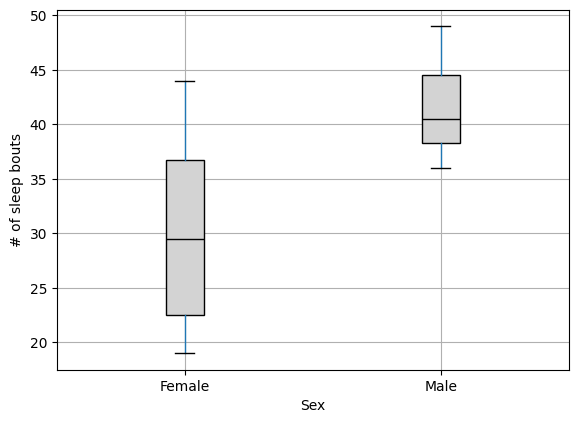

In [41]:
# boxplot( d$BOUT_N[ d$SS == "S" ]  ~ rep(c("Female","Male"),each=10) ,
#         xlab = "Sex" , ylab = "# of sleep bouts" )

df = df_stg[ df_stg.SS == 'S' ].copy()
df['Sex'] = ['Female'] * 10 + ['Male'] * 10  

df.boxplot(column='BOUT_N', by='Sex', patch_artist=True,
           boxprops=dict(facecolor='lightgray'),
           medianprops=dict(color='black'))
plt.xlabel("Sex")
plt.ylabel("# of sleep bouts")
plt.title("")  
plt.suptitle("")  
plt.show()

## NREM cycle metrics

In [43]:
#d <- k$HYPNO$C
#d <- merge( d , p , by="ID" )

df_cyc = pd.merge( p , df_cyc , on = 'ID' ) 
df_cyc = safe_to_numeric( df_cyc )
df_cyc

,ID,male,age,C,NREMC_MINS,NREMC_N,NREMC_NREM_MINS,NREMC_OTHER_MINS,NREMC_REM_MINS,NREMC_START
0,F01,0,41,1.0,158.0,316,121.5,13.5,23.0,84
1,F01,0,41,2.0,102.5,205,83.0,5.5,14.0,406
2,F01,0,41,3.0,73.0,146,47.0,4.0,22.0,630
3,F01,0,41,4.0,17.5,35,16.5,1.0,0.0,802
4,F02,0,32,1.0,71.5,143,53.0,3.0,15.5,41
...,...,...,...,...,...,...,...,...,...,...
70,M09,1,40,4.0,97.5,195,74.0,7.5,16.0,737
71,M10,1,41,1.0,129.5,259,102.0,13.5,14.0,19
72,M10,1,41,2.0,122.5,245,88.5,6.0,28.0,285
73,M10,1,41,3.0,108.0,216,80.0,13.0,15.0,547


In [50]:
# tapply( d$NREMC_MINS , list( d$C, d$male  ) , mean )
# (here for the first 4 cycles only, as we selected that above)
df_cyc.groupby(['C', 'male'])['NREMC_MINS'].mean().unstack().reset_index()

male,C,0,1
0,1.0,125.150000,109.350000
1,2.0,93.600000,114.000000
2,3.0,87.450000,97.722222
3,4.0,67.428571,65.000000


In [51]:
# sex effects for # and mean duration of each NREM cycle [ 
fit_lms( ['NREMC', 'NREMC_MINS'] , df_base )

,Var,Beta,p-value
0,NREMC,0.304822,0.498471
1,NREMC_MINS,-8.833357,0.286033


## Hypnogram visualization

In [52]:
#d <- k$HYPNO$E
df = proj.table( 'HYPNO' , 'E' )

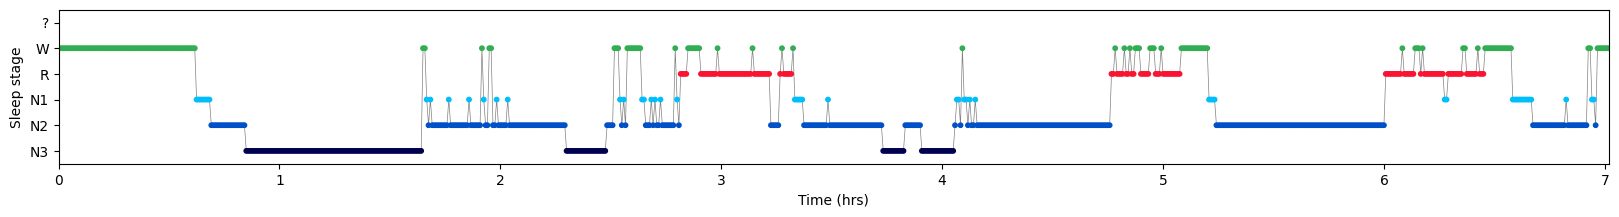

In [54]:
#lhypno( d$STAGE[ d$ID == "F01" ] )
lp.hypno( df.OSTAGE[ df.ID == 'F01' ] ) 

## Summary

Based on extracting a set of common hypnogram-derived metrics describing sleep macro-architecture in males and females, we can conclude that:

 - males spent more time in bed, despite not showing significant differences in TST, sleep onset latency, sleep efficiency or WASO

 - males had relatively more NREM sleep, females had relatively more REM

 - there were no obvious differences in NREM cycle structure

Even here, given the small sample it would be incautious to make strong conclusions, due to the threat of both false positive (multiple testing) and false negative (low power) errors. We'll address both issues later, by a) using methods to correct for multiple testing, and b) querying the larger remaining GRINS control sample for the same tests.

---
Now we can move on to the [next section](002_tf.ipynb).